In [124]:
import gymnasium as gym
from gymnasium.wrappers import FrameStackObservation
from gymnasium.wrappers import ResizeObservation
import ale_py
import math
import random
import matplotlib
import matplotlib.pyplot as plt
from collections import namedtuple, deque
from itertools import count
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

In [125]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)

is_ipython = 'inline' in matplotlib.get_backend()
if is_ipython:
    from IPython import display

plt.ion() # interactive on

nbFrameStack = 4


# Reinforcement Learning With **Pong**

In [126]:
env = gym.make("ALE/Qbert-v5", obs_type="grayscale")
print(env.observation_space.shape)
env = ResizeObservation(env, (84, 84)) 
print(env.observation_space.shape)
env = FrameStackObservation(env, stack_size=nbFrameStack)

(210, 160)
(84, 84)


In [127]:
class DQN(nn.Module):
    def __init__(self, n_FrameStack, n_actions):
      super(DQN, self).__init__()

      self.model = nn.Sequential(
          nn.Conv2d(in_channels=n_FrameStack, out_channels=32, kernel_size=8, stride=4),
          nn.ReLU(),
          nn.Conv2d(in_channels=32, out_channels=64, kernel_size=4, stride=2),
          nn.ReLU(),
          nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1),
          nn.ReLU())

      self.stateValue = nn.Sequential(
          nn.Linear(3136,512),
          nn.ReLU(),
          nn.Linear(512,1))

      self.advantage = nn.Sequential(
          nn.Linear(3136,512),
          nn.ReLU(),
          nn.Linear(512,n_actions))


    def forward(self, x):
      temp = self.model(x)
      temp = torch.flatten(temp, start_dim=1, end_dim=-1)
      sValue = self.stateValue(temp)
      advantage = self.advantage(temp)

      return sValue + (advantage - torch.mean(advantage, dim=1, keepdim=True))

In [128]:
Transition = namedtuple('Transition',
                        ('state', 'action', 'next_state', 'reward', 'gameIsOver'))

class ReplayMemory(object):

    def __init__(self, capacity):
      self.buffer = deque([], maxlen=capacity)

    def push(self, *args):
      self.buffer.append(Transition(*args))

    def sample(self, batch_size):
      return random.sample(self.buffer, batch_size)

    def __len__(self):
      return len(self.buffer)

In [129]:
class SmallMemory(object):

    def __init__(self, nStep, gamma):
      self.gamma = gamma
      self.buffer = deque([], maxlen=nStep)

    def push(self, *args):
      if len(self.buffer) < self.buffer.maxlen :
        self.buffer.append(Transition(*args))
      else : 
        state = self.buffer[0].state
        action = self.buffer[0].action
        next_state = self.buffer[-1].next_state
        sum_reward = 0
        for i in range(self.buffer.maxlen) :
          sum_reward += self.buffer[i].reward*(self.gamma**i)

        gameIsOver = self.buffer[-1].gameIsOver
        prevTransition = Transition(state, action, next_state, sum_reward, gameIsOver)
        self.buffer.append(Transition(*args))
        return prevTransition

    def flush(self) :
      transitionsList = []
      while len(self.buffer) > 0 :
        state = self.buffer[0].state
        action = self.buffer[0].action
        next_state = self.buffer[-1].next_state
        sum_reward = 0
        for i in range(len(self.buffer)) :
          sum_reward += self.buffer[i].reward*(self.gamma**i)

        gameIsOver = self.buffer[-1].gameIsOver
        prevTransition = Transition(state, action, next_state, sum_reward, gameIsOver)
        self.buffer.popleft()
        transitionsList.append(prevTransition)
      return transitionsList

    def __len__(self):
      return len(self.buffer)


## Hyperparameters

In [130]:
BATCH_SIZE = 128
GAMMA = 0.99
EPS_START = 0.9
EPS_END = 0.01
EPS_DECAY = 500000
TAU = 0.005
LR = 3e-4
REPLAY_BUFFER_SIZE = 100000
trainingFrequency = 4
nbActions = env.action_space.n

steps_done = 0
episode_durations = []

In [131]:
onlineNetwork = DQN(n_FrameStack=nbFrameStack, n_actions=nbActions).to(device)

targetNetwork = DQN(n_FrameStack=nbFrameStack, n_actions=nbActions).to(device)

targetNetwork.load_state_dict(onlineNetwork.state_dict())

optimizer = optim.AdamW(onlineNetwork.parameters(), lr=LR, amsgrad=True)
memory = ReplayMemory(REPLAY_BUFFER_SIZE)

In [132]:
def select_action(state, net, epsDecay, epsEnd, epsStart, numberStep):
  epsilon = epsEnd + (epsStart - epsEnd) * math.exp(-numberStep/epsDecay)

  if torch.rand(1).item() < epsilon :
    action = torch.randint(0,nbActions, (1,)).item()

  else :
    with torch.no_grad():
      action = torch.argmax(net(state)).item()

  return action

In [133]:
def calculateQlearning(targetNetwork, batch_nextState, batch_done, batch_reward, nStep) :
    with torch.no_grad() :
        next_predictions = targetNetwork(batch_nextState)
        maxQvalue = torch.max(next_predictions, dim=1).values
        bellmanTarget = batch_reward + (GAMMA**nStep) * (maxQvalue*~batch_done) #Multiplied by the inversed boolean : if game is finished -> True = 1, by inverting i assign 0 as a value when the game is finished
        
    return bellmanTarget

In [134]:
def calculateDoublelearning(onlineNetwork, targetNetwork, batch_nextState, batch_done, batch_reward, nStep) :
    with torch.no_grad() :
        next_predictions = onlineNetwork(batch_nextState)
        otherPrediction = targetNetwork(batch_nextState)
    
        maxQvalue = torch.gather(otherPrediction, dim=1, index=torch.argmax(next_predictions, dim=1).unsqueeze(1)).squeeze(1)

        bellmanTarget = batch_reward + (GAMMA**nStep) * (maxQvalue*~batch_done) #Multiplied by the inversed boolean : if game is finished -> True = 1, by inverting i assign 0 as a value when the game is finished
    
    return bellmanTarget

In [135]:
def optimizeModel(onlineNetwork, targetNetwork, optimizer, memory, duelingMode = True, nStep = 1) : #Les booleens ne sont pas une bonne pratiques de clean code :(

  if len(memory) < BATCH_SIZE :
    return

  state = []
  action = []
  nextState = []
  reward = []
  done = []

  for tuples in memory.sample(BATCH_SIZE) :
    state.append(tuples.state)
    action.append(tuples.action)
    nextState.append(tuples.next_state)
    reward.append(tuples.reward)
    done.append(tuples.gameIsOver)

  batch_state = torch.cat(state).to(device)
  batch_action = torch.tensor(action, device=device)
  batch_nextState = torch.cat(nextState).to(device)
  batch_reward = torch.tensor(reward, device=device)
  batch_done = torch.tensor(done, dtype=torch.bool, device=device)

  if duelingMode :
    bellmanTarget = calculateQlearning(targetNetwork, batch_nextState, batch_done, batch_reward, nStep)
  
  else :
    bellmanTarget = calculateDoublelearning(onlineNetwork, targetNetwork, batch_nextState, batch_done, batch_reward, nStep)

  actual_predictions = onlineNetwork(batch_state)

  policyPrediction = torch.gather(actual_predictions, 1, batch_action.unsqueeze(1))

  criterion = nn.SmoothL1Loss()

  loss = criterion(policyPrediction, bellmanTarget.unsqueeze(1))

  # Optimize the model
  optimizer.zero_grad()
  loss.backward()

  # In-place gradient clipping
  torch.nn.utils.clip_grad_value_(onlineNetwork.parameters(), 100)
  optimizer.step()

In [136]:
def trainModel(num_episodes = 600, numGameAVG = 5, duelingMode = True, nStep = 1, weightName = "Model") :
  finalScore = []

  for game in range(numGameAVG) :
    finalGameScore = []
    steps_done = 0

    onlineNetwork = DQN(n_FrameStack=nbFrameStack, n_actions=nbActions).to(device)

    targetNetwork = DQN(n_FrameStack=nbFrameStack, n_actions=nbActions).to(device)

    targetNetwork.load_state_dict(onlineNetwork.state_dict())

    optimizer = optim.AdamW(onlineNetwork.parameters(), lr=LR, amsgrad=True)
    memory = ReplayMemory(REPLAY_BUFFER_SIZE)

    for i_episode in range(num_episodes):
      nStepMemory = SmallMemory(nStep, GAMMA)

      currentGameScore = 0

      if i_episode == 0:
        state, info = env.reset(seed=game)
      else :
        state, info = env.reset()
      state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0) /255.0

      for t in count():
          action = select_action(state, onlineNetwork, EPS_DECAY, EPS_END, EPS_START, steps_done)
          observation, reward, terminated, truncated, _ = env.step(action)

          currentGameScore += reward

          reward_tensor = torch.tensor([reward], device=device)
          next_state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0) /255.0
          done = terminated or truncated

          prevTrans = nStepMemory.push(state, action, next_state, reward_tensor, done)

          if prevTrans is not None :
            # Store the transition in memory
            memory.push(*prevTrans)
            
          # Move to the next state
          state = next_state

          # Perform one step of the optimization (on the policy network)
          if steps_done % trainingFrequency == 0:

            optimizeModel(onlineNetwork, targetNetwork, optimizer, memory, duelingMode, nStep)

            # Soft update of the target network's weights
            # θ′ ← τ θ + (1 −τ )θ′
            target_net_state_dict = targetNetwork.state_dict()
            policy_net_state_dict = onlineNetwork.state_dict()
            for key in policy_net_state_dict:
                target_net_state_dict[key] = policy_net_state_dict[key]*TAU + target_net_state_dict[key]*(1-TAU)
            targetNetwork.load_state_dict(target_net_state_dict)

          steps_done += 1

          if done :
              lastMoves = nStepMemory.flush()
              for transitions in lastMoves:
                  memory.push(*transitions)

              finalGameScore.append(currentGameScore)
              episode_durations.append(t + 1)
              break
      print(f"Episode n°{i_episode}")
      print(f"reward : {currentGameScore}")
      print("=" *20)

    finalScore.append(finalGameScore)

  torch.save(onlineNetwork.state_dict(), weightName)
  return finalScore

Episode n°0
reward : 250.0
Episode n°1
reward : 0.0
Episode n°2
reward : 275.0
Episode n°3
reward : 100.0
Episode n°4
reward : 350.0
Episode n°5
reward : 125.0
Episode n°6
reward : 25.0
Episode n°7
reward : 75.0
Episode n°8
reward : 75.0
Episode n°9
reward : 125.0
Episode n°10
reward : 1075.0
Episode n°11
reward : 250.0
Episode n°12
reward : 50.0
Episode n°13
reward : 125.0
Episode n°14
reward : 575.0
Episode n°15
reward : 0.0
Episode n°16
reward : 275.0
Episode n°17
reward : 450.0
Episode n°18
reward : 150.0
Episode n°19
reward : 100.0
Episode n°20
reward : 100.0
Episode n°21
reward : 50.0
Episode n°22
reward : 100.0
Episode n°23
reward : 200.0
Episode n°24
reward : 250.0
Episode n°25
reward : 150.0
Episode n°26
reward : 125.0
Episode n°27
reward : 150.0
Episode n°28
reward : 100.0
Episode n°29
reward : 150.0
Episode n°30
reward : 75.0
Episode n°31
reward : 200.0
Episode n°32
reward : 250.0
Episode n°33
reward : 175.0
Episode n°34
reward : 25.0
Episode n°35
reward : 0.0
Episode n°36
r

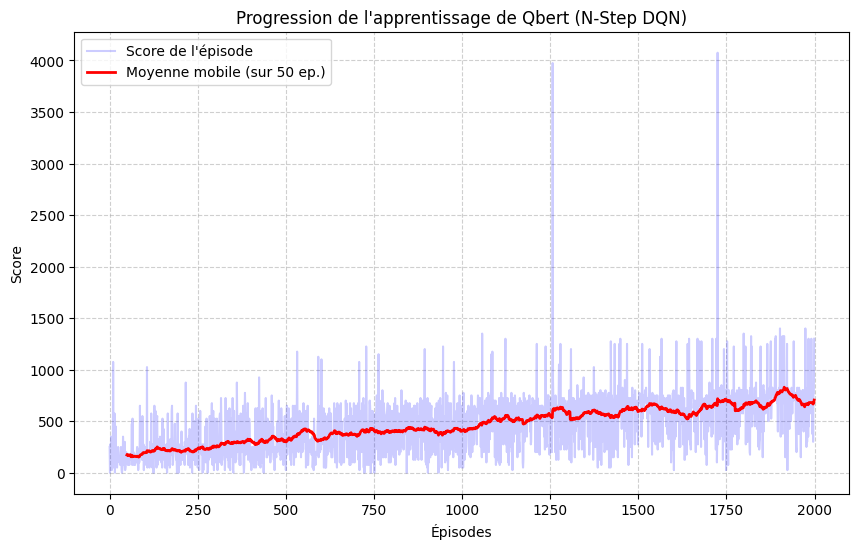

In [137]:
finalScore = trainModel(2000, 1, nStep=3, weightName="Qbert3-Step.pth")

# 2. On récupère la liste des scores de la première (et unique) run
scores_bruts = finalScore[0] 

# 3. On calcule la moyenne mobile sur une fenêtre (ex: 50 épisodes)
fenetre = 50
scores_lisses = pd.Series(scores_bruts).rolling(window=fenetre).mean()

# 4. On crée un beau graphique
plt.figure(figsize=(10, 6))

# On trace les scores bruts en arrière-plan (très transparent) pour voir la variance
plt.plot(scores_bruts, alpha=0.2, color='blue', label='Score de l\'épisode')

# On trace la courbe lissée par-dessus, bien visible
plt.plot(scores_lisses, color='red', linewidth=2, label=f'Moyenne mobile (sur {fenetre} ep.)')

plt.title("Progression de l'apprentissage de Qbert (N-Step DQN)")
plt.xlabel("Épisodes")
plt.ylabel("Score")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()